## **Loading the Libraries and Dataset**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('IPL.csv')

In [ ]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59


Basic Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

Check the size and rows of the column

In [ ]:
df.shape

(74, 20)

How many columns have null-values in total

In [ ]:
df.isna().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


Which team won the most matches

Text(0.5, 1.0, 'Which team won the most matches')

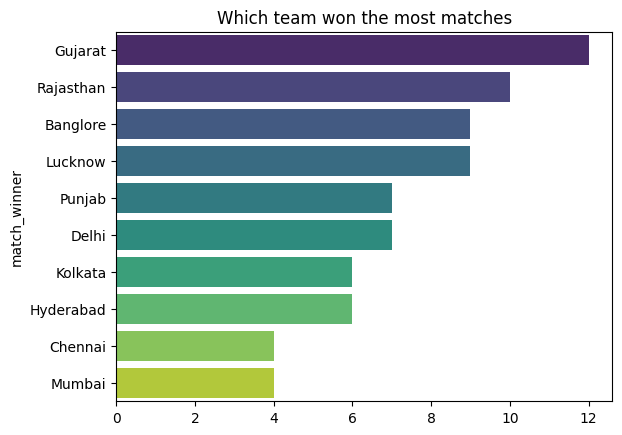

In [ ]:
max_winner_idx = df['match_winner'].value_counts()
sns.barplot(y = max_winner_idx.index, x=max_winner_idx.values, palette='viridis')
plt.title('Which team won the most matches')

Toss Decision trends

Text(0.5, 1.0, 'Toss Decision trends')

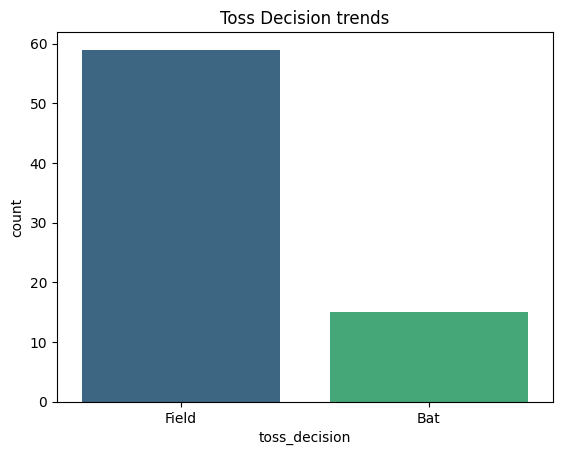

In [ ]:
sns.countplot(x = df['toss_decision'], palette='viridis')
plt.title("Toss Decision trends")

Toss Match vs Match winner

In [ ]:
count = df[df['toss_winner'] == df['match_winner']]['match_id'].count()
percentage = (count*100) / df.shape[0]
percentage.round(2)


np.float64(48.65)

How do Teams win? ( Runs v/s Wickets)

<Axes: xlabel='won_by'>

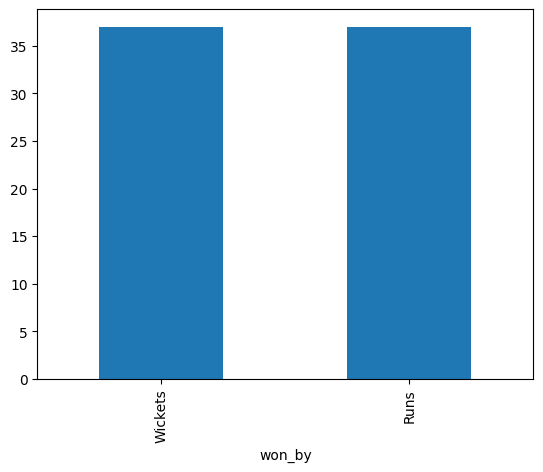

In [ ]:

df['won_by'].value_counts().plot(kind='bar')

Most players of the match awards

<Axes: ylabel='player_of_the_match'>

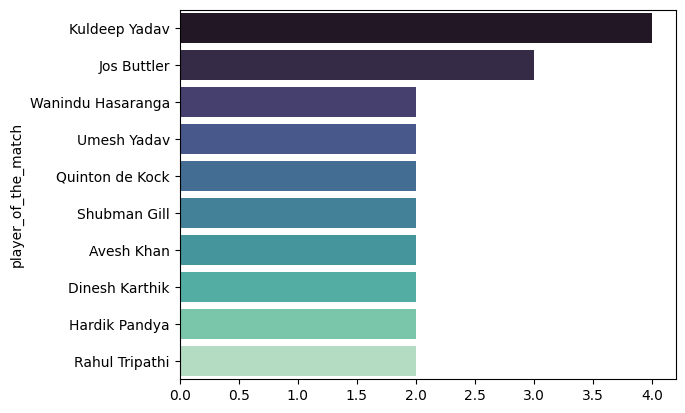

In [ ]:
awards = df['player_of_the_match'].value_counts().head(10)
sns.barplot(x=awards.values, y=awards.index, palette='mako')

Top 2 scorers

<Axes: xlabel='highscore'>

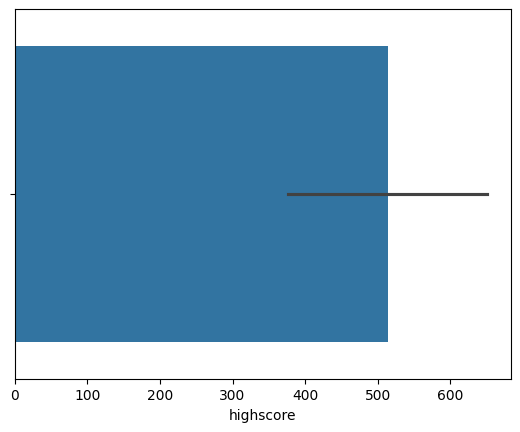

In [ ]:
high = df.groupby('top_scorer')['highscore'].sum().sort_values(ascending=False).head(2)
high.plot(kind='bar')

10 Best Bowling Figures

In [ ]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])
df['highest_wickets'] = df['highest_wickets'].astype(int)

In [ ]:
top_bowlers = df.groupby('best_bowling')['highest_wickets'].sum().sort_values(ascending=False).head(10)

<Axes: ylabel='best_bowling'>

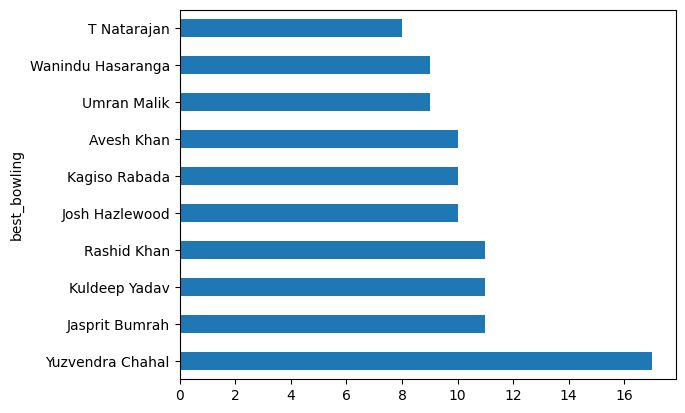

In [ ]:
top_bowlers.plot(kind='barh')

#### **Most Matches played by Venue**

Most matches Played by Venue

In [ ]:
venue_count = df['venue'].value_counts()
venue_count

,count
venue,
"Wankhede Stadium, Mumbai",21
"Dr DY Patil Sports Academy, Mumbai",20
"Brabourne Stadium, Mumbai",16
"Maharashtra Cricket Association Stadium,Pune",13
"Eden Gardens, Kolkata",2
"Narendra Modi Stadium, Ahmedabad",2


<Axes: ylabel='venue'>

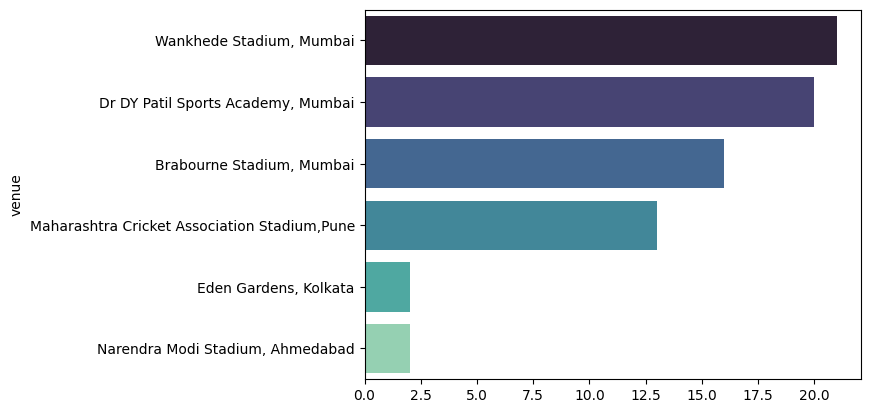

In [ ]:
# venue_count.plot(kind='barh')
sns.barplot(y= venue_count.index, x= venue_count.values, palette='mako')

#### **Questions & Insights**

Who won the highest margin by runs ?

In [ ]:
df[df['won_by'] == 'Runs'].sort_values(by='margin', ascending=False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


Which player has the highest individual score?

In [ ]:
df[df['highscore'] == df['highscore'].max()] [['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


Which Bowler had best bowling figure?

In [ ]:
df[df['highest_wickets'] == df['highest_wickets'].max()] [['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
